# Football Player Ranking Analysis

This notebook:

- reads the CSV file
- removes the timestamp column
- computes the mean, standard deviation, and number of votes for each player

The analysis uses raw player vote averages without row-wise normalization.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [30]:
csv_path = Path("Football player ranking.csv")

raw_df = pd.read_csv(csv_path)
raw_df.columns = raw_df.columns.str.strip().str.strip("[]")

votes_df = raw_df.drop(columns=["Timestamp"]).apply(pd.to_numeric, errors="coerce")
votes_df = votes_df.dropna(how="all")

print(f"Loaded {len(votes_df)} ballots and {votes_df.shape[1]} players.")
votes_df.head()

Loaded 13 ballots and 43 players.


,Vardan,Artur Mirzoyan,Nikolay,Edgar Galstyan,Erick Serra,Manu Monteiro,Mikayel Grigoryan,Paulo Góis,Rachid,Richard,...,Adeeb Sidani,Afonso Mota,Andre Yeran,Artem,Bachar,Boris Nogachev,David Mamulyan,Khaled,Patrick,Luis
0,9.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,9.0,10.0,...,NaN,NaN,NaN,4.0,NaN,7.0,NaN,NaN,NaN,NaN
1,7.0,5.0,7.0,7.0,NaN,8.0,7.0,6.0,8.0,8.0,...,6.0,10.0,5.0,6.0,5.0,5.0,7.0,5.0,9.0,9.0
2,7.0,5.0,NaN,NaN,NaN,10.0,8.0,NaN,9.0,9.0,...,7.0,9.0,6.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN
3,8.0,3.0,NaN,7.0,NaN,9.0,7.0,NaN,8.0,9.0,...,7.0,9.0,6.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
4,8.0,NaN,NaN,8.0,NaN,7.0,7.0,NaN,9.0,9.0,...,NaN,10.0,6.0,NaN,7.0,7.0,8.0,NaN,NaN,NaN


In [31]:
def normalize_row(
    row: pd.Series,
    new_min: float = 1,
    new_max: float = 10,
    old_min: float = 1,
    old_max: float = 10,
) -> pd.Series:
    valid = row.dropna()
    result = pd.Series(np.nan, index=row.index, dtype=float)

    if valid.empty:
        return result

    # Only one rating: convert from original 1–10 scale to the new scale
    if len(valid) == 1:
        normalized = (
            new_min
            + (new_max - new_min)
            * (valid - old_min)
            / (old_max - old_min)
        )
        result.loc[valid.index] = normalized
        return result

    row_min = valid.min()
    row_max = valid.max()

    # Multiple ratings but all identical: also convert from original 1–10 scale
    if row_max == row_min:
        normalized = (
            new_min
            + (new_max - new_min)
            * (valid - old_min)
            / (old_max - old_min)
        )
        result.loc[valid.index] = normalized
        return result

    # Normal case: correct for voter scale using row-wise min-max normalization
    normalized = (
        new_min
        + (new_max - new_min)
        * (valid - row_min)
        / (row_max - row_min)
    )

    result.loc[valid.index] = normalized
    return result


#normalized_df = votes_df.apply(normalize_row, axis=1)
normalized_df = votes_df
normalized_df.head()

,Vardan,Artur Mirzoyan,Nikolay,Edgar Galstyan,Erick Serra,Manu Monteiro,Mikayel Grigoryan,Paulo Góis,Rachid,Richard,...,Adeeb Sidani,Afonso Mota,Andre Yeran,Artem,Bachar,Boris Nogachev,David Mamulyan,Khaled,Patrick,Luis
0,9.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,9.0,10.0,...,NaN,NaN,NaN,4.0,NaN,7.0,NaN,NaN,NaN,NaN
1,7.0,5.0,7.0,7.0,NaN,8.0,7.0,6.0,8.0,8.0,...,6.0,10.0,5.0,6.0,5.0,5.0,7.0,5.0,9.0,9.0
2,7.0,5.0,NaN,NaN,NaN,10.0,8.0,NaN,9.0,9.0,...,7.0,9.0,6.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN
3,8.0,3.0,NaN,7.0,NaN,9.0,7.0,NaN,8.0,9.0,...,7.0,9.0,6.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
4,8.0,NaN,NaN,8.0,NaN,7.0,7.0,NaN,9.0,9.0,...,NaN,10.0,6.0,NaN,7.0,7.0,8.0,NaN,NaN,NaN


In [32]:
summary = pd.DataFrame({
    "mean_normalized_score": normalized_df.mean(axis=0, skipna=True).round(1).fillna(0),
    "std_normalized_score": normalized_df.std(axis=0, skipna=True).round(1).fillna(0),
    "number_of_votes": normalized_df.count(axis=0).astype(int)
}).sort_values(by="mean_normalized_score", ascending=False)

summary

,mean_normalized_score,std_normalized_score,number_of_votes
Robert Hovhannisyan,9.6,0.5,11
Afonso Mota,9.6,0.7,9
Luis,9.2,0.4,5
Richard,8.3,1.1,10
Manu Monteiro,8.2,1.9,9
Rachid,8.0,0.8,10
Ievon Yeghiazaryan,7.9,0.7,11
Francisco David,7.9,0.6,10
Patrick,7.7,2.3,3
Vardan,7.6,0.7,12


In [33]:
output_path = Path("football_player_ranking_summary.csv")
summary.to_csv(output_path)
print(f"Saved summary to {output_path.resolve()}")

Saved summary to C:\Users\adbva\my_different\FC_Ararat_Porto\football_player_ranking_summary.csv


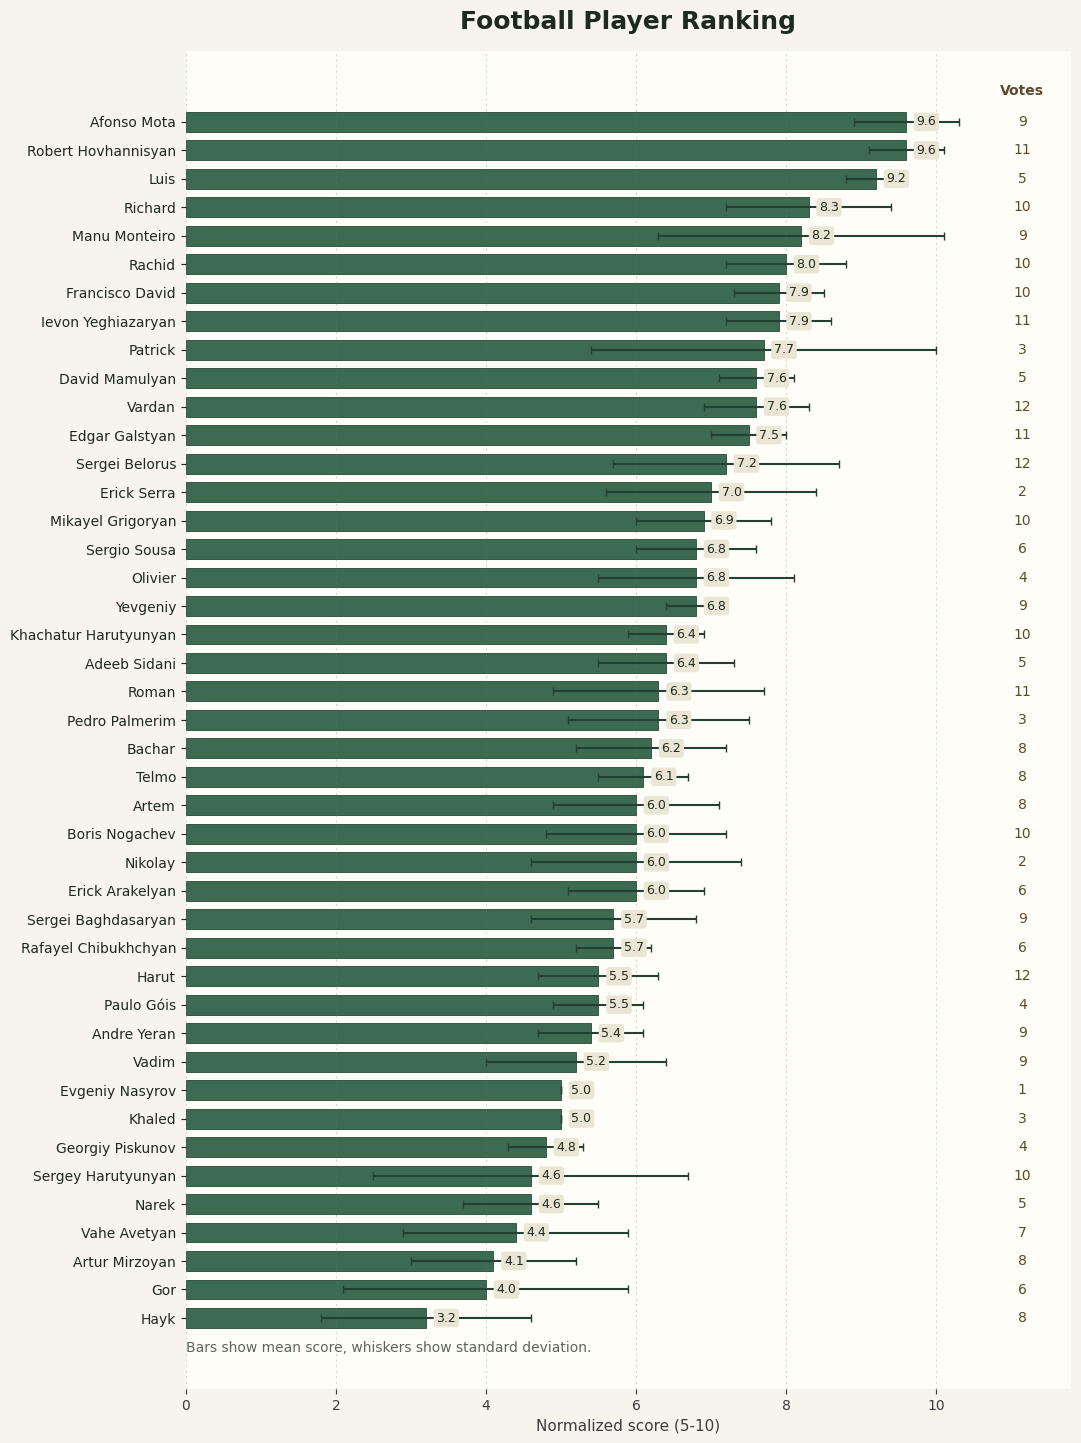

Saved chart to C:\Users\adbva\my_different\FC_Ararat_Porto\football_player_ranking_chart.png


In [ ]:
plot_df = summary.sort_values(by="mean_normalized_score", ascending=True)

# Taller layout keeps names readable when shared on mobile.
fig_height = max(8, len(plot_df) * 0.34)
fig, ax = plt.subplots(figsize=(11, fig_height), facecolor="#f7f4ed")
ax.set_facecolor("#fffdf8")

bar_color = "#3d6b52"
error_color = "#244030"
bars = ax.barh(
    plot_df.index,
    plot_df["mean_normalized_score"],
    xerr=plot_df["std_normalized_score"],
    color=bar_color,
    edgecolor="#294837",
    linewidth=0.6,
    ecolor=error_color,
    capsize=3,
    height=0.7,
)

ax.set_title("Football Player Ranking", fontsize=18, weight="bold", pad=16, color="#1f2a1f")
ax.set_xlabel("Average score", fontsize=11, color="#3c3c3c")
ax.set_ylabel("")
ax.set_xlim(0, 11.8)
ax.grid(axis="x", linestyle=(0, (2, 3)), alpha=0.28, color="#6d7b6d")
ax.tick_params(axis="y", labelsize=10, colors="#1f2a1f")
ax.tick_params(axis="x", labelsize=10, colors="#3c3c3c")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

vote_x = 11.15
ax.text(vote_x, len(plot_df) - 0.15, "Votes", ha="center", va="bottom", fontsize=10, weight="bold", color="#5a4a2f")

for bar, value, votes in zip(bars, plot_df["mean_normalized_score"], plot_df["number_of_votes"]):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        value + 0.14,
        y,
        f"{value:.1f}",
        va="center",
        fontsize=9,
        color="#1f2a1f",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="#ebe5d6", edgecolor="none"),
    )
    ax.text(vote_x, y, f"{int(votes)}", ha="center", va="center", fontsize=10, color="#5a4a2f")

ax.text(0, -1.2, "Bars show mean score, whiskers show standard deviation.", fontsize=10, color="#5d665d")

plt.tight_layout(pad=1.4)

image_path = Path("football_player_ranking_chart.png")
fig.savefig(image_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved chart to {image_path.resolve()}")

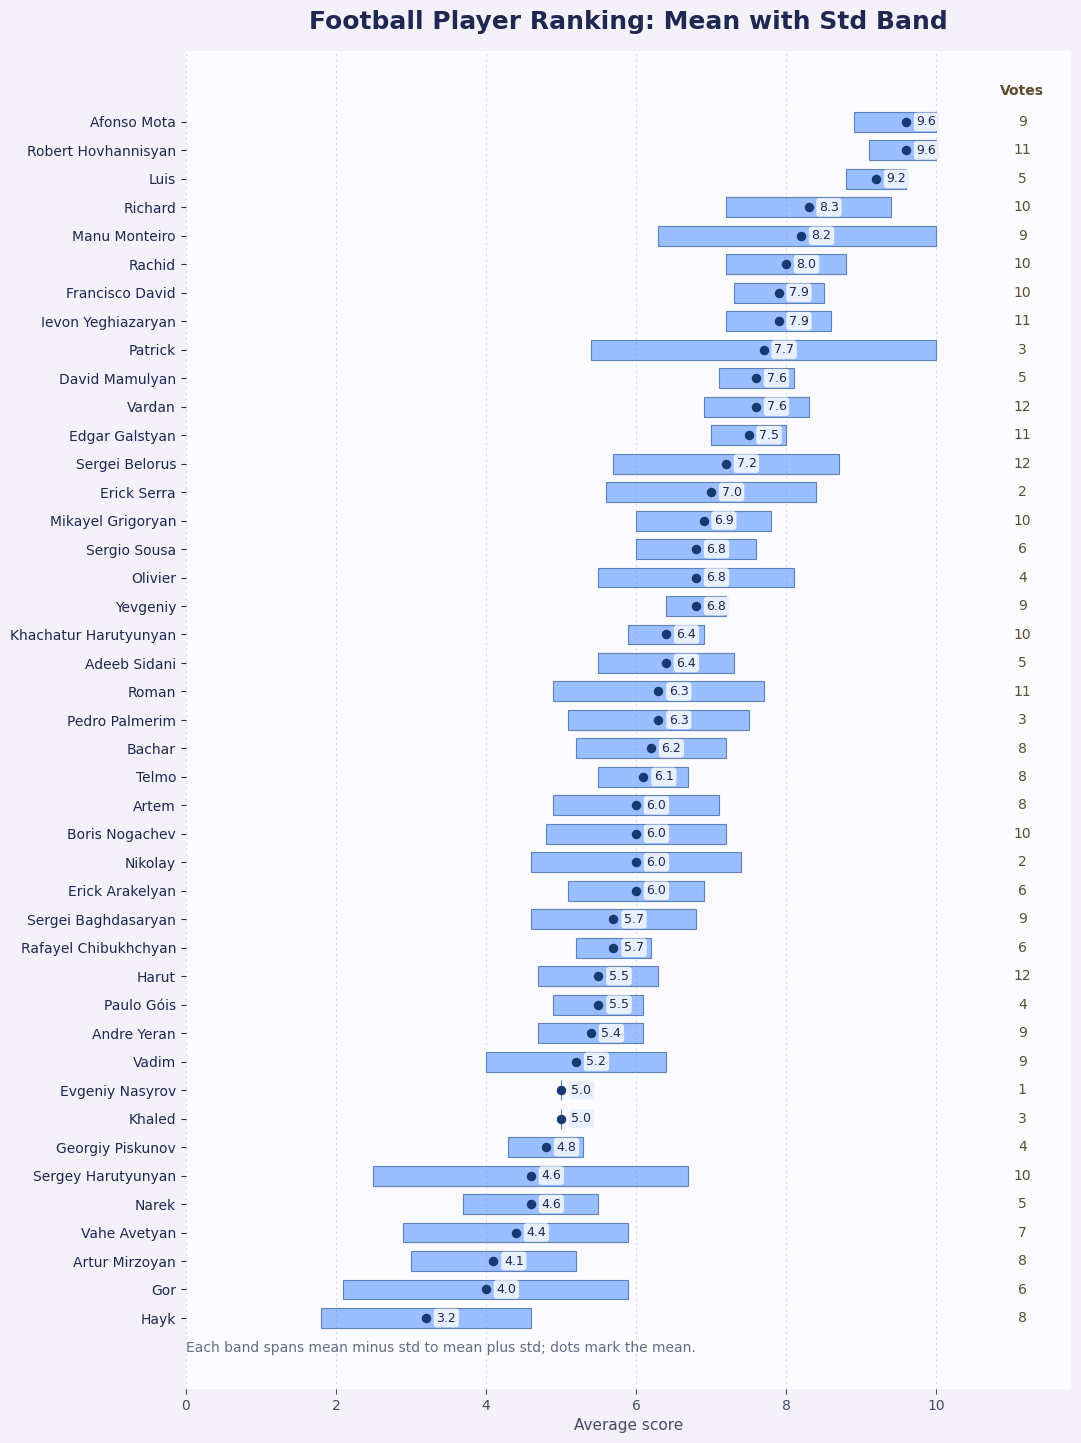

Saved chart to C:\Users\adbva\my_different\FC_Ararat_Porto\football_player_ranking_std_band_chart.png


In [35]:
spread_df = summary.sort_values(by="mean_normalized_score", ascending=True).copy()
spread_df["lower"] = (spread_df["mean_normalized_score"] - spread_df["std_normalized_score"]).clip(lower=1)
spread_df["upper"] = (spread_df["mean_normalized_score"] + spread_df["std_normalized_score"]).clip(upper=10)
spread_df["width"] = spread_df["upper"] - spread_df["lower"]

fig_height = max(8, len(spread_df) * 0.34)
fig, ax = plt.subplots(figsize=(11, fig_height), facecolor="#f4f1fb")
ax.set_facecolor("#fcfbff")

ax.barh(
    spread_df.index,
    spread_df["width"],
    left=spread_df["lower"],
    color="#8fb8ff",
    edgecolor="#5077b8",
    linewidth=0.8,
    height=0.7,
    alpha=0.9,
)

ax.scatter(
    spread_df["mean_normalized_score"],
    spread_df.index,
    color="#183a73",
    s=34,
    zorder=3,
)

ax.set_title("Football Player Ranking: Mean with Std Band", fontsize=18, weight="bold", pad=16, color="#1e2850")
ax.set_xlabel("Average score", fontsize=11, color="#434a62")
ax.set_ylabel("")
ax.set_xlim(0, 11.8)
ax.grid(axis="x", linestyle=(0, (2, 3)), alpha=0.28, color="#7984a0")
ax.tick_params(axis="y", labelsize=10, colors="#1e2850")
ax.tick_params(axis="x", labelsize=10, colors="#434a62")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

vote_x = 11.15
ax.text(vote_x, len(spread_df) - 0.15, "Votes", ha="center", va="bottom", fontsize=10, weight="bold", color="#5c4d2d")

for _, row in spread_df.iterrows():
    ax.text(
        row["mean_normalized_score"] + 0.14,
        row.name,
        f"{row['mean_normalized_score']:.1f}",
        va="center",
        fontsize=9,
        color="#1e2850",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="#e8efff", edgecolor="none"),
    )
    ax.text(vote_x, row.name, f"{int(row['number_of_votes'])}", ha="center", va="center", fontsize=10, color="#5c4d2d")

ax.text(0, -1.2, "Each band spans mean minus std to mean plus std; dots mark the mean.", fontsize=10, color="#636d84")

plt.tight_layout(pad=1.4)

spread_image_path = Path("football_player_ranking_std_band_chart.png")
fig.savefig(spread_image_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved chart to {spread_image_path.resolve()}")

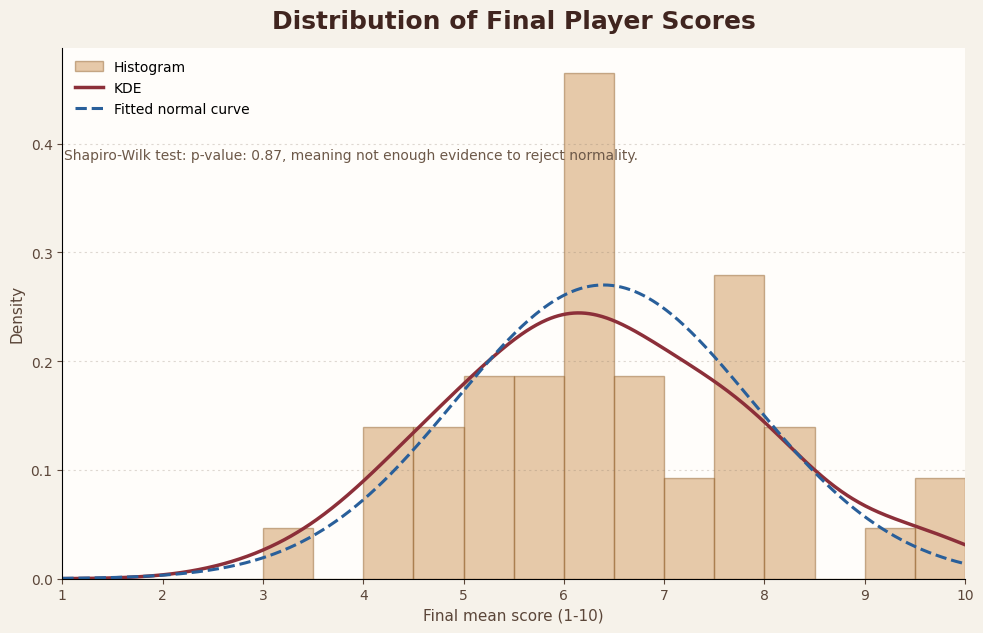

Saved chart to C:\Users\adbva\my_different\FC_Ararat_Porto\football_player_ranking_distribution.png
Shapiro-Wilk normality test
- What it does: compares the sample distribution to a normal distribution.
- Null hypothesis: the data comes from a normal distribution.
- Rule of thumb: if p-value < 0.05, we reject normality.
- W statistic: 0.9859
- p-value: 0.8686
- Interpretation: not enough evidence to reject normality.


In [36]:
final_scores = summary["mean_normalized_score"].dropna()
mu, sigma = stats.norm.fit(final_scores)
x = np.linspace(1, 10, 400)
normal_pdf = stats.norm.pdf(x, mu, sigma)
shapiro_stat, shapiro_p = stats.shapiro(final_scores)

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor="#f6f2ea")
ax.set_facecolor("#fffdfa")

bins = np.arange(1, 10.5, 0.5)
ax.hist(
    final_scores,
    bins=bins,
    density=True,
    color="#c98b47",
    edgecolor="#8c5a24",
    alpha=0.45,
    label="Histogram",
)

final_scores.plot(kind="kde", ax=ax, color="#8c2f39", linewidth=2.5, label="KDE")
ax.plot(x, normal_pdf, color="#295f9a", linewidth=2.2, linestyle="--", label="Fitted normal curve")

ax.set_title("Distribution of Final Player Scores", fontsize=18, weight="bold", pad=14, color="#40251f")
ax.set_xlabel("Final mean score (1-10)", fontsize=11, color="#5b4639")
ax.set_ylabel("Density", fontsize=11, color="#5b4639")
ax.set_xlim(1, 10)
ax.grid(axis="y", linestyle=(0, (2, 3)), alpha=0.28, color="#8a7a6a")
ax.tick_params(axis="both", labelsize=10, colors="#5b4639")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc="upper left")
#ax.text(1.02, ax.get_ylim()[1] * 0.93, f"n = {len(final_scores)} players", fontsize=10, color="#6c5848")
#ax.text(1.02, ax.get_ylim()[1] * 0.86, f"Normal fit: mu = {mu:.2f}, sigma = {sigma:.2f}", fontsize=10, color="#6c5848")
shapiro_result = "not enough evidence to reject normality" if shapiro_p >= 0.05 else "evidence to reject normality"
ax.text(1.02, ax.get_ylim()[1] * 0.79, f"Shapiro-Wilk test: p-value: {shapiro_p:.2f}, meaning {shapiro_result}.", fontsize=10, color="#6c5848")

plt.tight_layout(pad=1.3)

distribution_image_path = Path("football_player_ranking_distribution.png")
fig.savefig(distribution_image_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved chart to {distribution_image_path.resolve()}")
print("Shapiro-Wilk normality test")
print("- What it does: compares the sample distribution to a normal distribution.")
print("- Null hypothesis: the data comes from a normal distribution.")
print("- Rule of thumb: if p-value < 0.05, we reject normality.")
print(f"- W statistic: {shapiro_stat:.4f}")
print(f"- p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("- Interpretation: evidence against normality.")
else:
    print("- Interpretation: not enough evidence to reject normality.")